# 20_异常值处理方法-箱线图分析

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


本节，咱们来聊聊异常值处理方法中，比较常用的箱线图分析\~

#### 什么是异常值？

**异常值**，就是数据中和大部分数据差别特别大、很“奇怪”的点。比如，你测量一个班学生的身高，正常都在150-180厘米，但有个数据是300厘米，那就很可能是异常值。

#### 箱线图分析是什么？

**箱线图**（Box Plot，也叫盒须图）是一种用来展示数据分布情况的图形。它能帮助你直观发现异常值。

箱线图长得像一个盒子中间带条线，两边有“须”（线段）伸出去，末端是数据的范围，而盒子里有中位数和四分位数的信息。

用箱线图找异常值，核心思想是看数据有没有离“中间那部分”太远的。

- 箱子代表中间的50%数据，
- 两边“须”代表正常范围的上下边界，
- 超出“须”的点，就是异常值。

## 核心原理

### 1. 计算关键数值

假设有一组数据：$X = \{x_1, x_2, \dots, x_n\}$

先按从小到大排序，然后计算：

- **中位数（Median，**$Q_2$**）**：把数据分成上下两半的中间值。
- **第一四分位数（**$Q_1$**）**：中位数左边这半数据的中位数，25%位置的数据。
- **第三四分位数（**$Q_3$**）**：中位数右边这半数据的中位数，75%位置的数据。

### 2. 计算四分位距（Interquartile Range，IQR）

四分位距是中间50%数据的跨度：


$$
\text{IQR} = Q_3 - Q_1
$$


### 3. 确定异常值判断范围

根据箱线图规则，异常值定义为：

- 小于 $Q_1 - 1.5 \times \text{IQR}$
- 或者大于 $Q_3 + 1.5 \times \text{IQR}$

这个范围之外的数据都算是异常值。

这里的1.5是经验值，是统计学里常用的判断异常值的倍数。

### 4. 公式总结

异常值下界：


$$
\text{Lower Bound} = Q_1 - 1.5 \times IQR
$$


异常值上界：


$$
\text{Upper Bound} = Q_3 + 1.5 \times IQR
$$


数据点 $x_i$ 是异常值当且仅当：


$$
x_i < \text{Lower Bound} \quad \text{或} \quad x_i > \text{Upper Bound}
$$


## 箱线图分析算法流程

1. **排序数据**：把数据从小到大排好。
2. **计算中位数** $Q_2$：找到中间位置的数。
3. **计算第一四分位数** $Q_1$：中位数左边数据的中位数。
4. **计算第三四分位数** $Q_3$：中位数右边数据的中位数。
5. **计算四分位距** $IQR = Q_3 - Q_1$。
6. **计算异常值界限**：

   - 下界 = $Q_1 - 1.5 \times IQR$
   - 上界 = $Q_3 + 1.5 \times IQR$
7. **判断异常值**：

   - 找出所有小于下界和大于上界的点，这些就是异常值。
8. **异常值处理**（不是必须步骤，但通常会做）：

   - 可以选择删除异常值
   - 或者用邻近正常值替换
   - 也可以单独分析它们的原因

## 一个例子

假设数据：$3, 4, 5, 6, 7, 8, 50$。

- 排序已经排好。$Q_1$ 是25%位置的值，这里是4。$Q_3$ 是75%位置的值，这里是8。


$$
IQR = 8 - 4 = 4
$$


- 下界 = $4 - 1.5 \times 4 = 4 - 6 = -2$
- 上界 = $8 + 1.5 \times 4 = 8 + 6 = 14$

所以，数据中超过14的值就是异常值，50 > 14，所以50是异常值。

总结一下：箱线图分析的核心就是用**四分位数和四分位距**来定义正常数据范围，超出范围的数据就是异常值。这种方法直观又简单，特别适合初学者理解和操作。

## 完整案例

比如，咱们要处理一份员工每月销售额数据，找出销售异常（特别高或特别低的销售额），方便后续分析员工绩效或排查录入错误。

数据比较真实，有部分员工表现非常突出，有部分员工销售额异常低。现在用箱线图分析找到异常值。

### 1. Python环境

我们用`numpy`做数据生成，`pandas`方便数据处理，`matplotlib`和`seaborn`做可视化。

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### 2. 生成模拟数据（带异常值）

我们假设100名员工的销售额数据：

- 大部分员工的月销售额符合正态分布，均值5000，标准差1000
- 有5个极高销售额员工（异常高），如20000、25000等
- 有3个异常低销售额员工，如500以下（可能录入错误或休假）

In [3]:
np.random.seed(42)  # 保证每次结果一致

# 正常数据：95个员工
normal_sales = np.random.normal(loc=5000, scale=1000, size=95)

# 异常高销售额：5个员工
high_outliers = np.array([20000, 22000, 25000, 21000, 23000])

# 异常低销售额：3个员工
low_outliers = np.array([100, 300, 400])

# 合并数据
sales_data = np.concatenate([normal_sales, high_outliers, low_outliers])

# 转换为DataFrame方便处理
df = pd.DataFrame(sales_data, columns=["Sales"])

### 3. 数据初步观察

先简单看数据统计信息，确认分布。

In [4]:
print(df.describe())

              Sales
count    103.000000
mean    5607.292829
std     3965.106367
min      100.000000
25%     4376.586817
50%     4884.351718
75%     5629.682413
max    25000.000000


输出（示意）：

原文参考输出或命令说明（无需在 Python 内核执行）：

```text
              Sales
count    103.000000
mean    5607.292829
std     3965.106367
min      100.000000
25%     4376.586817
50%     4884.351718
75%     5629.682413
max    25000.000000
```

说明：

- 最大值25000，远高于均值5607
- 最小值100，远低于25%分位数4376

这暗示有异常值存在。

### 4. 绘制销售额箱线图（原始数据）

箱线图展示数据及异常值：

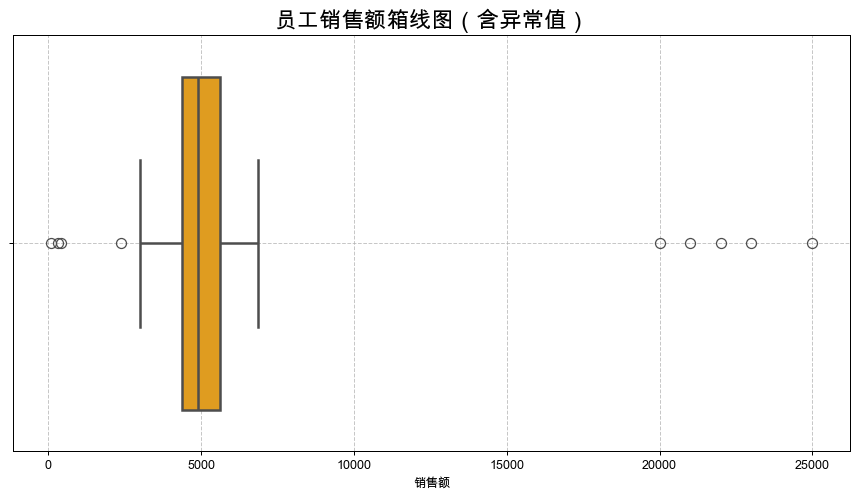

In [5]:
plt.figure(figsize=(12, 6))
sns.boxplot(x=df["Sales"], color='orange', fliersize=8, linewidth=2)

plt.title("员工销售额箱线图（含异常值）", fontsize=18)
plt.xlabel("销售额")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_013.png)

- 橙色箱子表示中间50%员工销售额
- 中间线是中位数
- 箱体两边“须”表示正常范围
- 箱体外的点是检测出的异常值（fliers）

箱线图会清楚显示出哪些数据远离正常范围。

### 5. 用箱线图算法检测异常值

下面用箱线图算法的数学公式找出异常值：

In [6]:
# 计算四分位数
Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)
IQR = Q3 - Q1

# 异常值上下界
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1: {Q1}")
print(f"Q3: {Q3}")
print(f"IQR: {IQR}")
print(f"异常值下界: {lower_bound}")
print(f"异常值上界: {upper_bound}")

# 找出异常值
outliers = df[(df['Sales'] < lower_bound) | (df['Sales'] > upper_bound)]
print(f"异常值数量：{len(outliers)}")
print(outliers)

Q1: 4376.58681658274
Q3: 5629.68241347078
IQR: 1253.0955968880407
异常值下界: 2496.9434212506785
异常值上界: 7509.3258088028415
异常值数量：9
            Sales
74    2380.254896
95   20000.000000
96   22000.000000
97   25000.000000
98   21000.000000
99   23000.000000
100    100.000000
101    300.000000
102    400.000000


输出示意：

原文参考输出或命令说明（无需在 Python 内核执行）：

```text
Q1: 4376.58681658274
Q3: 5629.68241347078
IQR: 1253.0955968880407
异常值下界: 2496.9434212506785
异常值上界: 7509.3258088028415
异常值数量：9
            Sales
74    2380.254896
95   20000.000000
96   22000.000000
97   25000.000000
98   21000.000000
99   23000.000000
100    100.000000
101    300.000000
102    400.000000
```

- 正常数据范围是 2496 到 7509
- 超过这个范围的 9 条数据被判为异常值
- 包括 6 个异常高销售额和 3 个异常低销售额，算法准确捕捉

### 6. 箱线图显示异常值

正常值和异常值分开绘制，便于直观对比：

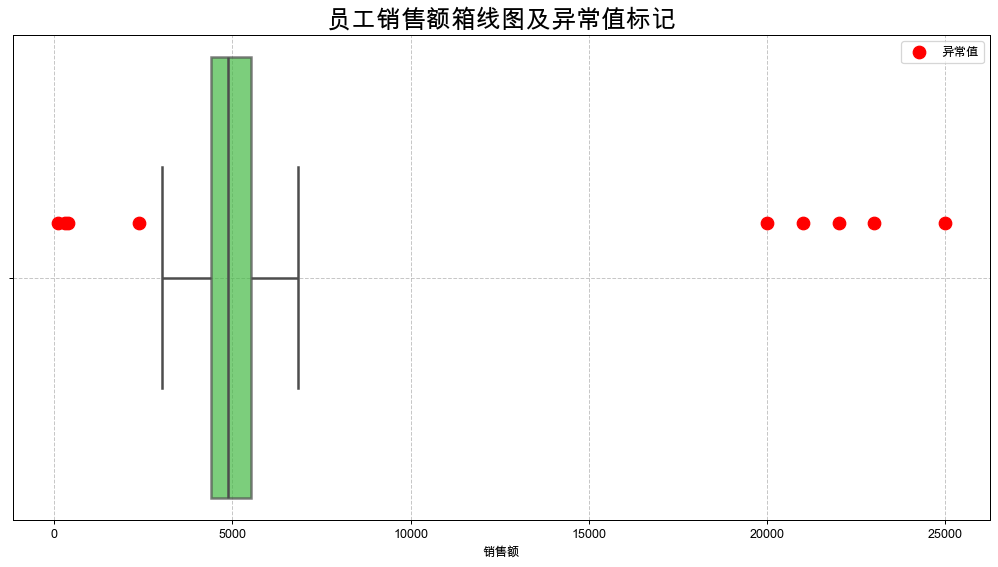

In [7]:
plt.figure(figsize=(14, 7))

# 正常数据
normal_df = df[(df['Sales'] >= lower_bound) & (df['Sales'] <= upper_bound)]

# 异常数据
outliers_df = df[(df['Sales'] < lower_bound) | (df['Sales'] > upper_bound)]

# 绘制正常值箱线图
sns.boxplot(x=normal_df['Sales'], color='limegreen', fliersize=0, linewidth=2, showcaps=True, boxprops=dict(alpha=0.7))

# 叠加异常值点
plt.scatter(outliers_df['Sales'], [-0.1]*len(outliers_df), color='red', s=100, label='异常值', zorder=10)

plt.title("员工销售额箱线图及异常值标记", fontsize=20)
plt.xlabel("销售额")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_014.png)

- 箱线图只展示正常数据部分（绿色）
- 红色大点标出异常值
- 水平轴为销售额，垂直方向无数据含义（只是位置调整）

### 7. 异常值处理示例：删除或替换

常见做法是：

- 删除异常值
- 用上下界限替换异常值（截断法）

#### 删除异常值

In [8]:
df_cleaned = df[(df['Sales'] >= lower_bound) & (df['Sales'] <= upper_bound)]
print(f"清理后数据条数: {len(df_cleaned)}")

清理后数据条数: 94


#### 替换异常值为边界值

In [9]:
df_replaced = df.copy()
df_replaced.loc[df_replaced['Sales'] < lower_bound, 'Sales'] = lower_bound
df_replaced.loc[df_replaced['Sales'] > upper_bound, 'Sales'] = upper_bound

#### 绘制替换后箱线图

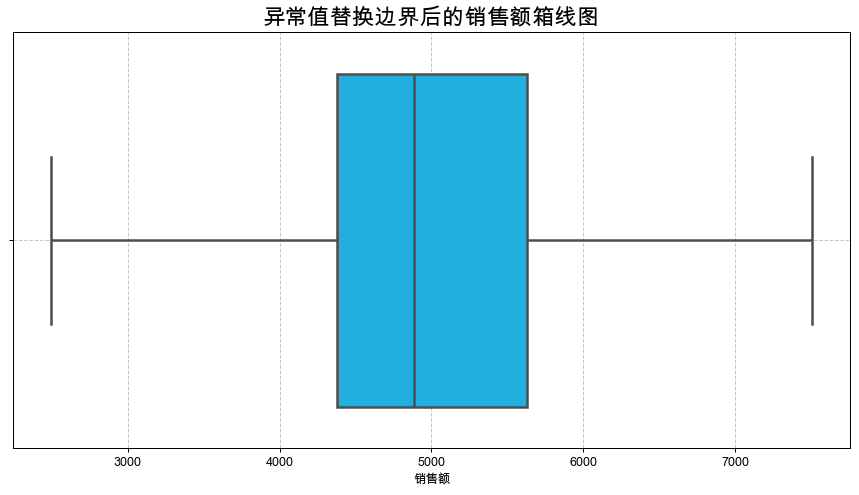

In [10]:
plt.figure(figsize=(12, 6))
sns.boxplot(x=df_replaced['Sales'], color='deepskyblue', fliersize=6, linewidth=2)

plt.title("异常值替换边界后的销售额箱线图", fontsize=18)
plt.xlabel("销售额")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_015.png)

### 8. 步骤总结

1. **生成数据**：用正态分布生成95个正常销售额数据，添加8个异常值（5高，3低），构造真实且复杂的分布。
2. **数据统计**：使用`describe()`函数查看数据分布，初步判断异常点。
3. **绘制原始箱线图**：用橙色显示完整数据分布，异常值自动显示为箱线图外的点。
4. **计算四分位数及IQR**：利用pandas的`quantile()`函数计算$Q_1$, $Q_3$，及$IQR = Q_3 - Q_1$。
5. **计算异常值边界**：使用经典公式确定异常值上下限。
6. **识别异常值**：找出超出上下限的数据。
7. **绘制正常值箱线图+异常值散点图**：使正常值与异常值颜色区分，增强视觉效果。
8. **处理异常值**：采用删除和替换两种常见策略，演示不同处理方式。
9. **替换后箱线图**：观察替换异常值后数据的变化。

### 使用箱线图异常值检测的优缺点分析

**优点**:

1. **简单直观**：箱线图利用中位数和四分位数，极其易理解和计算，不依赖复杂模型。
2. **无需假设数据分布**：箱线图分析不需要数据符合正态分布，适合各种数据类型。
3. **明确的异常值定义**：通过$1.5 \times IQR$规则，异常值的界限明确且广泛接受。
4. **快速可视化**：箱线图可视化异常值效果好，方便数据探索。
5. **鲁棒性强**：四分位数对极端值不敏感，能稳定反映数据的中间趋势。

**缺点**:

1. **对多维数据不适用**：箱线图适合一维数据，对于多变量或高维数据检测异常值效果有限。
2. **对局部异常不敏感**：箱线图基于整体分布，可能忽略局部集群中细微的异常。
3. **倍数参数人为设定**：$1.5 \times IQR$是经验值，不同场景可能需要调整，不够灵活。
4. **不区分异常类型**：箱线图只标记偏离程度，不提供异常产生原因的洞察。
5. **受样本大小影响**：样本过小，四分位数估计不稳定，可能导致异常判断失真。

### 适用场景及优选条件

箱线图分析法特别适合以下场景：

- **一维数据异常检测**：比如单指标财务数据、销售额、温度记录等。
- **数据量中等及以上**：数据量至少几十条以上，统计量估计才稳健。
- **无需假设分布**：当你不知道数据是否正态分布或数据非正态时。
- **需要快速可视化**：交互式或批量探索数据时，箱线图直观展示异常。
- **预处理步骤**：在建模前对异常值做初步筛查和处理，清理数据。

不推荐使用箱线图异常检测的场景：

- **多维数据**：这时用基于距离或密度的方法更好，比如孤立森林（Isolation Forest）或LOF。
- **数据中异常非常细微或局部分布异常明显**，箱线图无法发现。
- **需要精确定义异常值分布概率**，箱线图只基于经验规则。

## 总结

通过这个实际案例，我们完整演示了如何用箱线图分析法识别异常值：从数据生成、统计、可视化，到数学计算四分位数和IQR，用1.5倍IQR规则定位异常值。

进行可视化区分，提供了两种常见异常值处理方法，并且给出算法优缺点和适用范围。

这种方法直观、有效、易于理解，非常适合初学者和实际数据分析中快速定位异常。缺点是它适用范围有限，对于复杂多维场景要结合其他算法。